In [1]:
import numpy as np
import os 
import glob

In [2]:
directory = "appledataset"
parent_dir = os.getcwd()
path = os.path.join(parent_dir, directory)

os.mkdir(path)
print("Directory '%s' created" % directory)

Directory 'appledataset' created


In [4]:
directory =["train","test"]
parent_dir = 'appledataset'
for dire in directory:
    path = os.path.join(parent_dir,dire)
    os.mkdir(path)
    print(f"created: {dire} in {parent_dir}" )


created: train in appledataset
created: test in appledataset


In [20]:
path = "Fuji-SfM_dataset/1-Mask-set/validation_images_and_annotations"
dir_list = os.listdir(path)
print(len(dir_list))

115


In [16]:
import shutil
def move(source_folder, destination_folder):
    os.makedirs(destination_folder,exist_ok = True)
    for filename in os.listdir(source_folder):
        source_path = os.path.join(source_folder, filename)
        distination_path = os.path.join(destination_folder, filename)
        if os.path.isfile(source_path):
            shutil.move(source_path,  distination_path)
    print("all files are moved successfully!")

In [21]:
source_folder = "Fuji-SfM_dataset/1-Mask-set/validation_images_and_annotations"
destination_folder = "appledataset/test"
move(source_folder, destination_folder)

all files are moved successfully!


In [2]:
import pandas as pd

In [49]:
annotation_sample = pd.read_csv("appledataset/train/mask__MG_3004_02.csv")
##print(annotation_sample[['region_shape_attributes']])
first_row_x_points = json.loads(annotation_sample["region_shape_attributes"].iloc[0])["all_points_x"]
print(first_row_x_points)


[709, 708, 708, 706, 706, 705, 705, 702, 700, 699, 696, 695, 693, 692, 691, 688, 688, 689, 689, 696, 697, 698, 702, 703, 708, 709, 709]


In [11]:
from collections import Counter
files_path = "appledataset/train"
extensions = []
print(len(os.listdir(files_path)))
for files in os.listdir(files_path):
    if os.path.isfile(os.path.join(files_path,files)):
        ext = os.path.splitext(files)[1]
        extensions.append(ext)
format_counts = Counter( extensions)
print(format_counts)
    

464
Counter({'.csv': 231, '.jpg': 231, '.json': 1})


In [10]:
csv_files = sorted(glob.glob('appledataset/train/*.csv'))
print(f"found {len(csv_files)} csv files")
print(csv_files[1])

found 231 csv files
appledataset/train\mask__MG_3004_03.csv


Found 231 CSV files
[6] _MG_3004_09 — 15 apples annotated


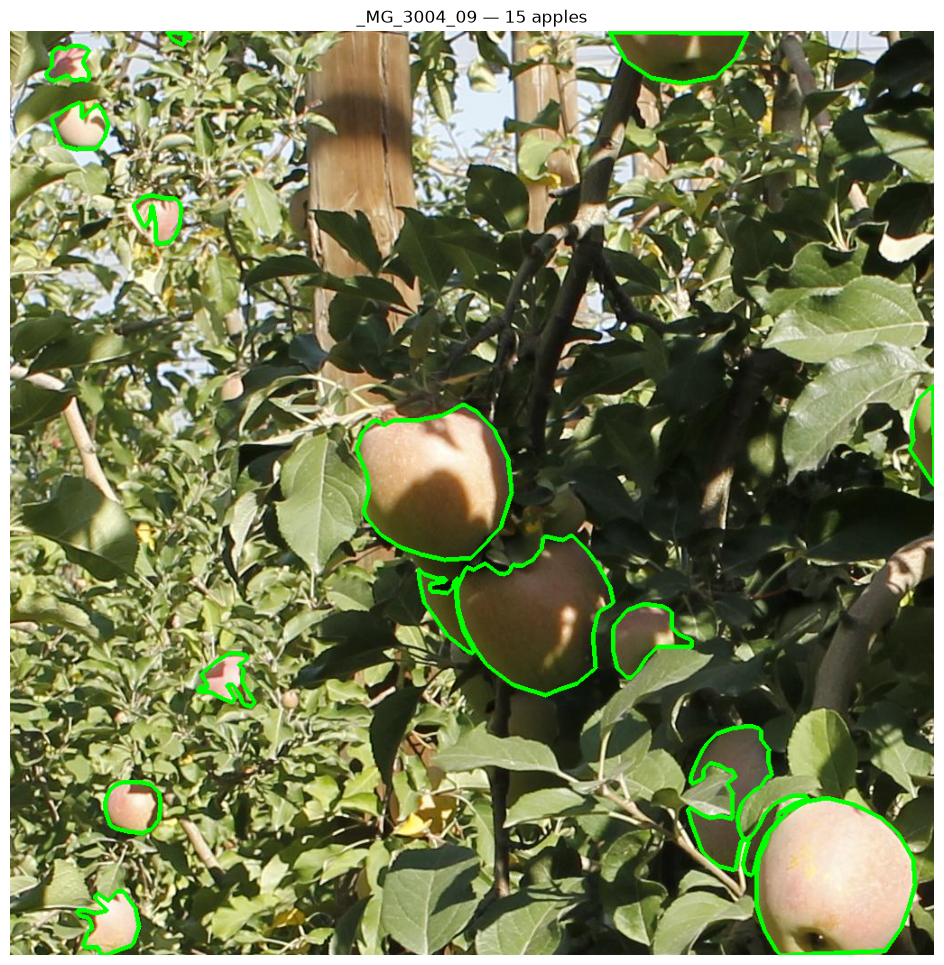

In [29]:
import pandas as pd
import json
import cv2
import matplotlib.pyplot as plt
import os
import glob

IMAGES_DIR = 'appledataset/train'
CSV_DIR = 'appledataset/train'

csv_files = sorted(glob.glob(os.path.join(CSV_DIR, 'mask__*.csv')))
print(f"Found {len(csv_files)} CSV files")


def visualize_by_index(index):
    csv_path = csv_files[index]
    csv_basename = os.path.basename(csv_path)
    image_basename = csv_basename.replace('mask_', '', 1)
    image_stem = os.path.splitext(image_basename)[0]

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(IMAGES_DIR, image_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        raise FileNotFoundError(f"No matching image found for {image_stem}")

    df = pd.read_csv(csv_path)   # <-- this was missing before

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for _, row in df.iterrows():
        shape_attr = row['region_shape_attributes']
        shape = json.loads(shape_attr) if isinstance(shape_attr, str) else shape_attr

        if shape.get('name') == 'polygon':
            xs = shape['all_points_x']
            ys = shape['all_points_y']
            pts = [(int(x), int(y)) for x, y in zip(xs, ys)]
            for i in range(len(pts)):
                cv2.line(img_rgb, pts[i], pts[(i + 1) % len(pts)], (0, 255, 0), 3)

    print(f"[{index}] {image_stem} — {len(df)} apples annotated")

    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"{image_stem} — {len(df)} apples")
    plt.show()



visualize_by_index(6)

In [30]:
"""
polygon_csv_to_yolo.py — Convert VIA-style polygon CSV annotations to YOLO bbox labels.
Each image has its own mask__<image_stem>.csv file containing one row per
apple polygon, in the region_shape_attributes column.
"""

import os
import glob
import json
import pandas as pd
from PIL import Image

IMAGES_DIR = 'appledataset/train'
CSV_DIR = 'appledataset/train'
YOLO_LABELS_OUT = 'appledataset/train/yolo_labels'

os.makedirs(YOLO_LABELS_OUT, exist_ok=True)

csv_files = sorted(glob.glob(os.path.join(CSV_DIR, 'mask__*.csv')))
print(f"Found {len(csv_files)} CSV files")

converted = 0
skipped = 0

for csv_path in csv_files:
    csv_basename = os.path.basename(csv_path)
    image_basename = csv_basename.replace('mask_', '', 1)
    image_stem = os.path.splitext(image_basename)[0]

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(IMAGES_DIR, image_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"Warning: no matching image for {image_stem}, skipping")
        skipped += 1
        continue

    with Image.open(img_path) as im:
        img_w, img_h = im.size

    df = pd.read_csv(csv_path)
    yolo_lines = []

    for _, row in df.iterrows():
        shape_attr = row['region_shape_attributes']
        shape = json.loads(shape_attr) if isinstance(shape_attr, str) else shape_attr

        if shape.get('name') != 'polygon':
            continue

        xs = shape['all_points_x']
        ys = shape['all_points_y']

        if len(xs) == 0 or len(ys) == 0:
            continue

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        # skip degenerate boxes
        if (x_max - x_min) < 2 or (y_max - y_min) < 2:
            continue

        x_center = ((x_min + x_max) / 2) / img_w
        y_center = ((y_min + y_max) / 2) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    label_path = os.path.join(YOLO_LABELS_OUT, image_stem + '.txt')
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

    converted += 1

print(f"\nDone. Converted: {converted}, Skipped (no image match): {skipped}")
print(f"YOLO labels written to: {YOLO_LABELS_OUT}")

Found 231 CSV files

Done. Converted: 231, Skipped (no image match): 0
YOLO labels written to: appledataset/train/yolo_labels


[TEST] _MG_3004_09 — 15 boxes


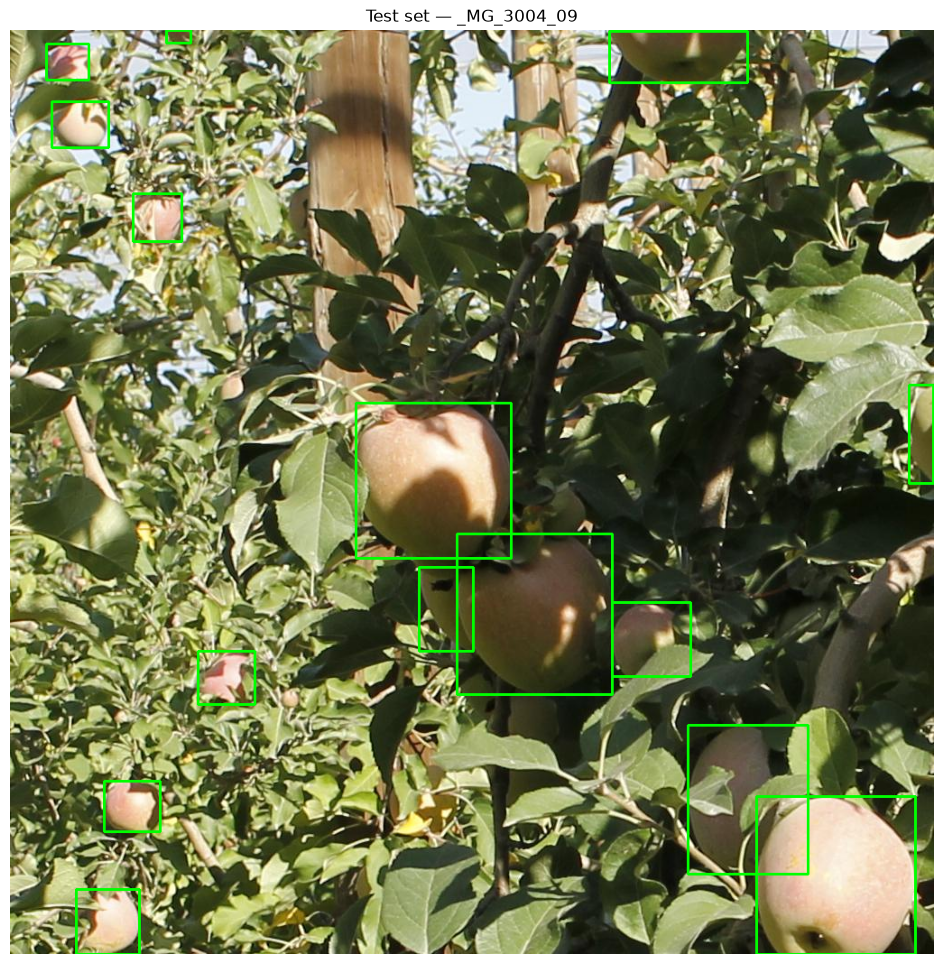

In [57]:
import cv2
import matplotlib.pyplot as plt
import os

TEST_IMAGES_DIR = 'appledataset/train'
TEST_YOLO_LABELS_OUT = 'appledataset/train/yolo_labels'
test_csv_files = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, 'mask__*.csv')))

def visualize_test_yolo_label(index):
    csv_path = test_csv_files[index]
    image_stem = os.path.splitext(os.path.basename(csv_path).replace('mask_', '', 1))[0]

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(TEST_IMAGES_DIR, image_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        raise FileNotFoundError(f"No matching image found for {image_stem}")

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    label_path = os.path.join(TEST_YOLO_LABELS_OUT, image_stem + '.txt')
    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        _, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    print(f"[TEST] {image_stem} — {len(lines)} boxes")

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Test set — {image_stem}")
    plt.show()

visualize_test_yolo_label(6)

In [50]:
"""
polygon_csv_to_yolo.py — Convert VIA-style polygon CSV annotations to YOLO bbox labels.
Each image has its own mask__<image_stem>.csv file containing one row per
apple polygon, in the region_shape_attributes column.
"""

import os
import glob
import json
import pandas as pd
from PIL import Image

IMAGES_DIR = 'appledataset/test'
CSV_DIR = 'appledataset/test'
YOLO_LABELS_OUT = 'appledataset/test/yolo_labels'

os.makedirs(YOLO_LABELS_OUT, exist_ok=True)

csv_files = sorted(glob.glob(os.path.join(CSV_DIR, 'mask__*.csv')))
print(f"Found {len(csv_files)} CSV files")

converted = 0
skipped = 0

for csv_path in csv_files:
    csv_basename = os.path.basename(csv_path)
    image_basename = csv_basename.replace('mask_', '', 1)
    image_stem = os.path.splitext(image_basename)[0]

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(IMAGES_DIR, image_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"Warning: no matching image for {image_stem}, skipping")
        skipped += 1
        continue

    with Image.open(img_path) as im:
        img_w, img_h = im.size

    df = pd.read_csv(csv_path)
    yolo_lines = []

    for _, row in df.iterrows():
        shape_attr = row['region_shape_attributes']
        shape = json.loads(shape_attr) if isinstance(shape_attr, str) else shape_attr

        if shape.get('name') != 'polygon':
            continue

        xs = shape['all_points_x']
        ys = shape['all_points_y']

        if len(xs) == 0 or len(ys) == 0:
            continue

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        # skip degenerate boxes
        if (x_max - x_min) < 2 or (y_max - y_min) < 2:
            continue

        x_center = ((x_min + x_max) / 2) / img_w
        y_center = ((y_min + y_max) / 2) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    label_path = os.path.join(YOLO_LABELS_OUT, image_stem + '.txt')
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

    converted += 1

print(f"\nDone. Converted: {converted}, Skipped (no image match): {skipped}")
print(f"YOLO labels written to: {YOLO_LABELS_OUT}")

Found 57 CSV files

Done. Converted: 57, Skipped (no image match): 0
YOLO labels written to: appledataset/test/yolo_labels


[TEST] _MG_3017_07 — 13 boxes


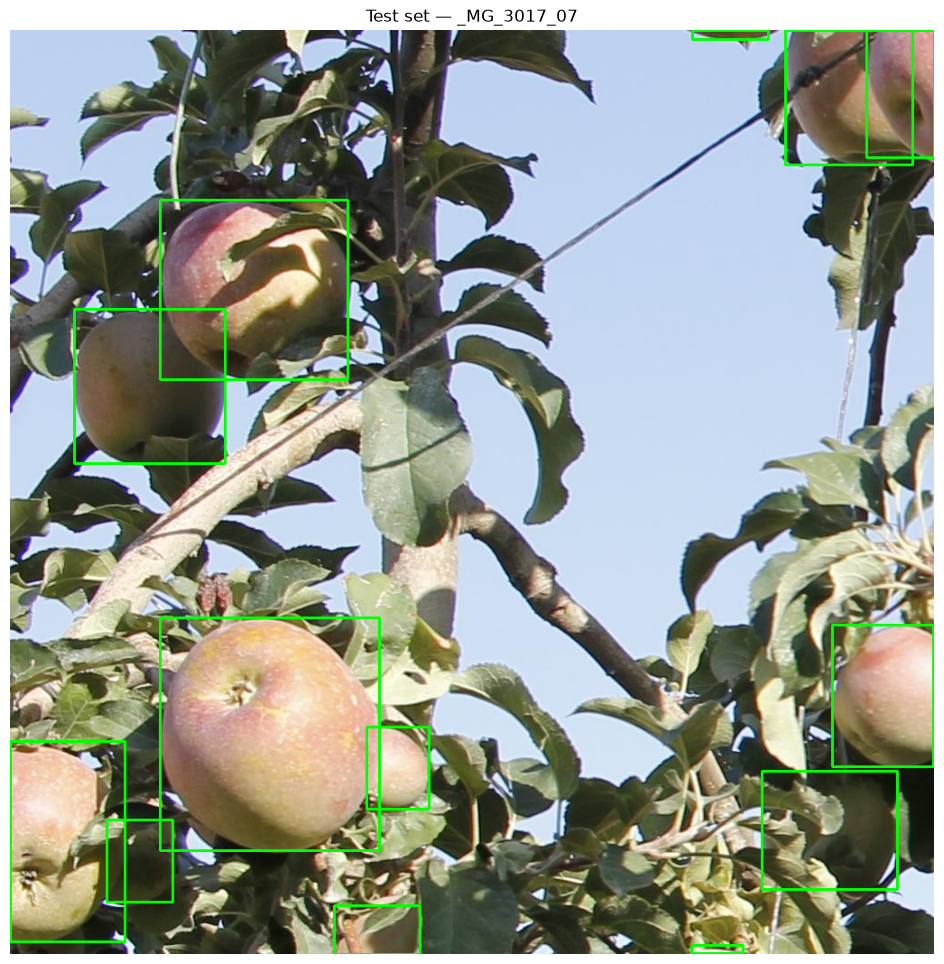

In [55]:
import cv2
import matplotlib.pyplot as plt
import os

TEST_IMAGES_DIR = 'appledataset/test'
TEST_YOLO_LABELS_OUT = 'appledataset/test/yolo_labels'
test_csv_files = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, 'mask__*.csv')))

def visualize_test_yolo_label(index):
    csv_path = test_csv_files[index]
    image_stem = os.path.splitext(os.path.basename(csv_path).replace('mask_', '', 1))[0]

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(TEST_IMAGES_DIR, image_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        raise FileNotFoundError(f"No matching image found for {image_stem}")

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    label_path = os.path.join(TEST_YOLO_LABELS_OUT, image_stem + '.txt')
    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        _, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    print(f"[TEST] {image_stem} — {len(lines)} boxes")

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Test set — {image_stem}")
    plt.show()

visualize_test_yolo_label(6)

In [59]:
target_folder = "appledataset/train"

# 1. Loop through the folder and all its subfolders
for dirpath, dirnames, filenames in os.walk(target_folder):
    for filename in filenames:
        
        # 2. Check if the file ends with .csv
        if filename.lower().endswith('.csv'):
            file_path = os.path.join(dirpath, filename)
            
            # 3. Safely attempt to delete the file
            try:
                os.remove(file_path)
                print(f"Deleted: {file_path}")
            except OSError as e:
                print(f"Could not delete {file_path}. Error: {e}")


Deleted: appledataset/train\mask__MG_3004_02.csv
Deleted: appledataset/train\mask__MG_3004_03.csv
Deleted: appledataset/train\mask__MG_3004_04.csv
Deleted: appledataset/train\mask__MG_3004_05.csv
Deleted: appledataset/train\mask__MG_3004_07.csv
Deleted: appledataset/train\mask__MG_3004_08.csv
Deleted: appledataset/train\mask__MG_3004_09.csv
Deleted: appledataset/train\mask__MG_3004_10.csv
Deleted: appledataset/train\mask__MG_3004_12.csv
Deleted: appledataset/train\mask__MG_3004_13.csv
Deleted: appledataset/train\mask__MG_3004_14.csv
Deleted: appledataset/train\mask__MG_3004_15.csv
Deleted: appledataset/train\mask__MG_3004_17.csv
Deleted: appledataset/train\mask__MG_3004_18.csv
Deleted: appledataset/train\mask__MG_3004_19.csv
Deleted: appledataset/train\mask__MG_3004_20.csv
Deleted: appledataset/train\mask__MG_3004_22.csv
Deleted: appledataset/train\mask__MG_3004_23.csv
Deleted: appledataset/train\mask__MG_3004_24.csv
Deleted: appledataset/train\mask__MG_3017_01.csv
Deleted: appledatase

In [3]:
print(os.getcwd())

C:\Users\Dell\OneDrive - City Community Education Consultancy Pvt. Ltd\Desktop\data-aggrigation


In [ ]:
import zipfile

def zip_folder(folder_path, output_path):
    # Create a ZipFile object in write mode
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Walk through all files and subfolders
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Preserve folder structure inside the zip
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)


zip_folder("appledataset", "appledataset.zip")
